In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)

ROOT = Path.cwd().parent
firms = pd.read_csv(
    ROOT / "data" / "processed" / "firms_kalimantan_2012_2026.csv",
    parse_dates=["tanggal"],
    low_memory=False,
)
sipongi = pd.read_csv(ROOT / "data" / "processed" / "luas_kalimantan_provinsi.csv")

print("FIRMS :", firms.shape)
print("SiPongi:", sipongi.shape)
firms.head(3)

Matplotlib is building the font cache; this may take a moment.


FIRMS : (1488643, 19)
SiPongi: (75, 6)


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type,tanggal,tahun,bulan,musim
0,-3.88574,115.10657,338.97,0.42,0.37,2012-01-20,538,N,VIIRS,n,2,295.79,5.82,D,0.0,2012-01-20,2012,1,basah
1,-3.62912,115.49331,356.33,0.40,0.37,2012-01-20,538,N,VIIRS,n,2,298.85,43.82,D,0.0,2012-01-20,2012,1,basah
2,-2.18322,115.98127,331.25,0.39,0.36,2012-01-20,539,N,VIIRS,n,2,289.68,3.12,D,0.0,2012-01-20,2012,1,basah


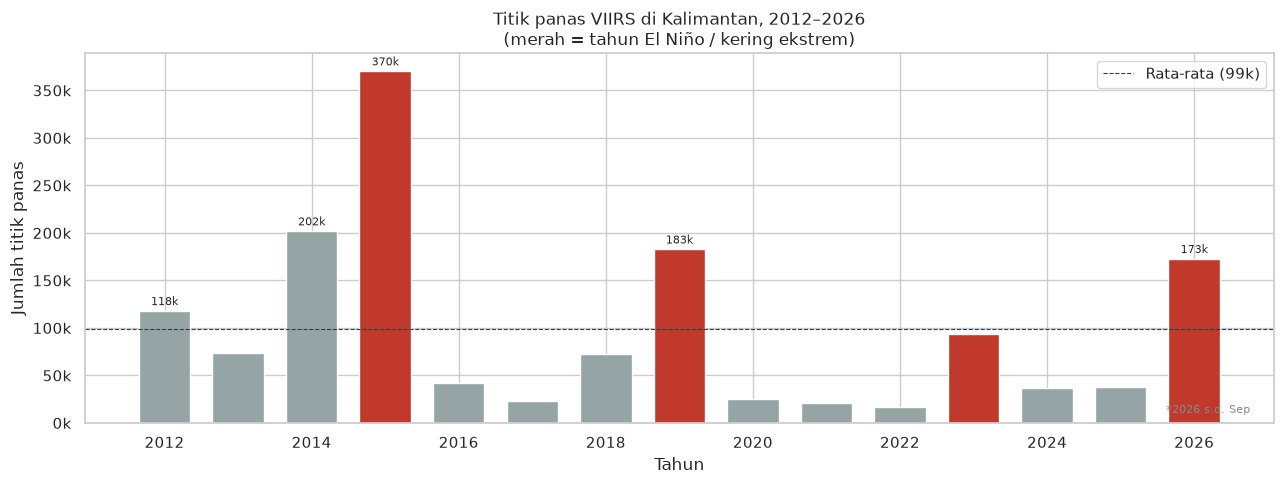

In [2]:
# Titik panas per tahun
per_tahun = firms.groupby("tahun").size().reset_index(name="titik_panas")

# Warnai tahun El Niño
el_nino = {2015, 2019, 2023, 2026}
warna = ["#c0392b" if t in el_nino else "#95a5a6" for t in per_tahun["tahun"]]

fig, ax = plt.subplots()
bars = ax.bar(per_tahun["tahun"], per_tahun["titik_panas"], color=warna, width=0.7)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.set_xlabel("Tahun")
ax.set_ylabel("Jumlah titik panas")
ax.set_title("Titik panas VIIRS di Kalimantan, 2012–2026\n(merah = tahun El Niño / kering ekstrem)")
ax.axhline(per_tahun["titik_panas"].mean(), color="#2c3e50", linestyle="--",
           linewidth=0.8, label=f"Rata-rata ({per_tahun['titik_panas'].mean()/1000:.0f}k)")

# Beri label di atas bar yang melebihi rata-rata
for bar, val, tahun in zip(bars, per_tahun["titik_panas"], per_tahun["tahun"]):
    if val > per_tahun["titik_panas"].mean():
        ax.text(bar.get_x() + bar.get_width()/2, val + 3000,
                f"{val/1000:.0f}k", ha="center", va="bottom", fontsize=8)

ax.legend()
ax.annotate("*2026 s.d. Sep", xy=(0.98, 0.02), xycoords="axes fraction",
            ha="right", va="bottom", fontsize=8, color="#7f8c8d")
plt.tight_layout()
plt.show()

 tahun  titik_panas   luas_ha  ha_per_titik
  2012       118213 374122.00          3.16
  2013        73452  88836.00          1.21
  2014       202166 641129.00          3.17
  2015       370497 957725.17          2.58
  2016        41750  62898.56          1.51
  2017        23277  18260.09          0.78
  2018        72148 243013.50          3.37
  2019       183026 684599.00          3.74
  2020        24795  26286.00          1.06
  2021        20934  37575.00          1.79
  2022        17144  24562.00          1.43
  2023        93804 508430.22          5.42
  2024        36464  65608.11          1.80
  2025        37977  55717.27          1.47


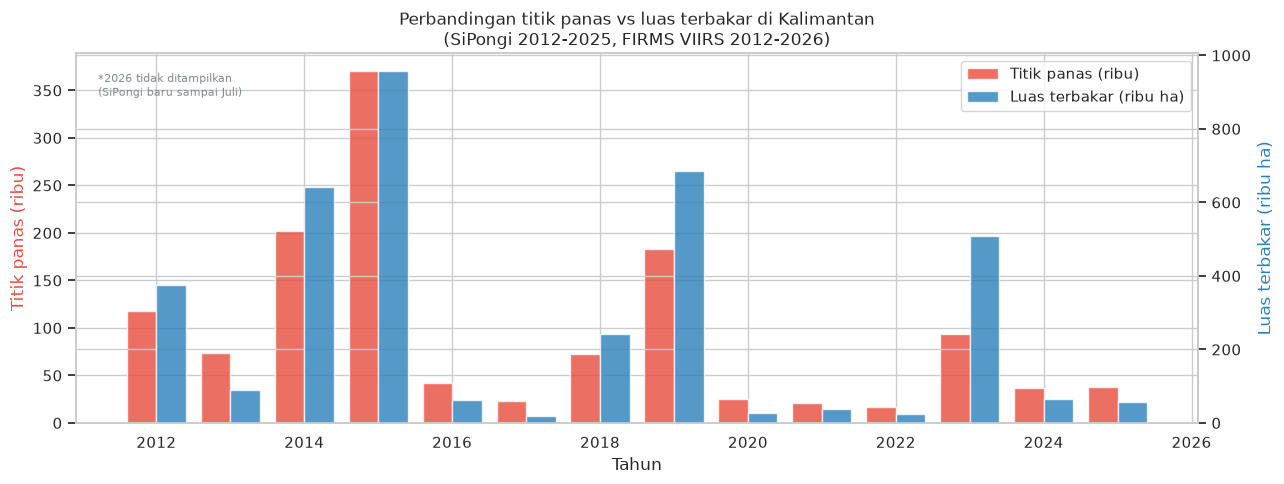

In [3]:
# Gabungkan dua sumber
per_tahun_prov = (
    firms.groupby(["tahun", "musim"])
    .size()
    .reset_index(name="titik_panas")
)

# Total titik panas per tahun, dan total luas terbakar Kalimantan per tahun
titik = firms.groupby("tahun").size().reset_index(name="titik_panas")

luas = (
    sipongi[sipongi["tahun_parsial"] == False]
    .groupby("tahun")["luas_ha"]
    .sum()
    .reset_index()
)

gabung = titik.merge(luas, on="tahun", how="inner")
gabung["ha_per_titik"] = gabung["luas_ha"] / gabung["titik_panas"]

print(gabung[["tahun", "titik_panas", "luas_ha", "ha_per_titik"]].round(2).to_string(index=False))

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

warna_titik = "#e74c3c"
warna_luas = "#2980b9"

ax1.bar(gabung["tahun"] - 0.2, gabung["titik_panas"] / 1000,
        width=0.4, color=warna_titik, alpha=0.8, label="Titik panas (ribu)")
ax2.bar(gabung["tahun"] + 0.2, gabung["luas_ha"] / 1000,
        width=0.4, color=warna_luas, alpha=0.8, label="Luas terbakar (ribu ha)")

ax1.set_ylabel("Titik panas (ribu)", color=warna_titik)
ax2.set_ylabel("Luas terbakar (ribu ha)", color=warna_luas)
ax1.set_xlabel("Tahun")
ax1.set_title("Perbandingan titik panas vs luas terbakar di Kalimantan\n(SiPongi 2012-2025, FIRMS VIIRS 2012-2026)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.annotate("*2026 tidak ditampilkan\n(SiPongi baru sampai Juli)",
             xy=(0.02, 0.95), xycoords="axes fraction",
             fontsize=8, color="#7f8c8d", va="top")

plt.tight_layout()
plt.show()

In [ ]:
# Distribusi titik panas per bulan, bandingkan tahun El Niño vs normal
firms["kategori"] = firms["tahun"].map(
    lambda t: "El Niño (2015/2019/2023)" if t in {2015, 2019, 2023}
    else ("2026" if t == 2026 else "Tahun lain")
)

per_bulan = (
    firms.groupby(["bulan", "kategori"])
    .size()
    .reset_index(name="titik_panas")
)

# Normalkan ke rata-rata per tahun supaya perbandingan adil
n_tahun = {"El Niño (2015/2019/2023)": 3, "2026": 1, "Tahun lain": 11}
per_bulan["per_tahun"] = per_bulan.apply(
    lambda r: r["titik_panas"] / n_tahun[r["kategori"]], axis=1
)

nama_bulan = ["Jan","Feb","Mar","Apr","Mei","Jun",
              "Jul","Agu","Sep","Okt","Nov","Des"]

fig, ax = plt.subplots()
for kat, grp in per_bulan.groupby("kategori"):
    grp = grp.sort_values("bulan")
    ax.plot(grp["bulan"], grp["per_tahun"] / 1000,
            marker="o", label=kat, linewidth=1.8)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(nama_bulan)
ax.set_ylabel("Rata-rata titik panas per tahun (ribu)")
ax.set_title("Pola musiman titik panas di Kalimantan\n(rata-rata per kelompok tahun)")
ax.legend()
plt.tight_layout()
plt.show()